In [4]:
# Income Prediction: Logistic Regression vs XGBoost
# Binary Classification Model Comparison

# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
import pandas as pd

# Load your preprocessed data
# IMPORTANT: Replace 'your_data.csv' with your actual filename
df_encoded = pd.read_csv('cleaned_encoded_dataset.csv')

# Display basic information
print("Dataset loaded successfully!")
print(f"\nDataset shape: {df_encoded.shape}")
print(f"\nFirst few rows:")
df_encoded.head()

Dataset loaded successfully!

Dataset shape: (28970, 32)

First few rows:


,age,education,education_num,occupation,sex,capital_gain,capital_loss,hours_per_week,native_country,income,workclass_local-gov,workclass_never-worked,workclass_private,workclass_self-emp-inc,workclass_self-emp-not-inc,workclass_state-gov,workclass_without-pay,marital_status_married-af-spouse,marital_status_married-civ-spouse,marital_status_married-spouse-absent,marital_status_never-married,marital_status_separated,marital_status_widowed,relationship_not-in-family,relationship_other-relative,relationship_own-child,relationship_unmarried,relationship_wife,race_asian-pac-islander,race_black,race_other,race_white
0,39,13,13,adm-clerical,1,2174,0,40,united-states,0,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True
1,50,13,13,exec-managerial,1,0,0,13,united-states,0,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
2,38,9,9,handlers-cleaners,1,0,0,40,united-states,0,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True
3,53,7,7,handlers-cleaners,1,0,0,40,united-states,0,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False
4,28,13,13,prof-specialty,0,0,0,40,cuba,0,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False


In [9]:
print("\n=== DATA PREPARATION ===")

# Define features (X) and target (y)
# Adjust column names based on YOUR data
X = df_encoded.drop(columns=['income', 'occupation', 'native_country'])
y = df_encoded['income']

# Split data into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"\nTarget distribution:\n{y_train.value_counts(normalize=True)}")


=== DATA PREPARATION ===
Training set: (20279, 29)
Testing set: (8691, 29)

Target distribution:
income
0    0.752157
1    0.247843
Name: proportion, dtype: float64


In [10]:
print("\n=== TRAINING LOGISTIC REGRESSION ===")

# Start timer
start_time = time.time()

# Create and train the model
lr_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Calculate training time
lr_train_time = time.time() - start_time

print(f"✓ Training completed in {lr_train_time:.2f} seconds")


=== TRAINING LOGISTIC REGRESSION ===
✓ Training completed in 0.15 seconds


In [11]:
print("\n=== TRAINING XGBOOST CLASSIFIER ===")

# Start timer
start_time = time.time()

# Create and train the model
xgb_model = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='logloss', 
    random_state=42, 
    n_estimators=100
)
xgb_model.fit(X_train, y_train)

# Calculate training time
xgb_train_time = time.time() - start_time

print(f"✓ Training completed in {xgb_train_time:.2f} seconds")


=== TRAINING XGBOOST CLASSIFIER ===
✓ Training completed in 0.21 seconds


/home/scc101/income_prediction_project/myenv/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [14:42:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [12]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluate a trained model and return metrics.
    """
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    metrics = {
        'AUC': roc_auc_score(y_test, y_pred_proba),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    return metrics, cm

print("✓ Evaluation function created")

✓ Evaluation function created


In [13]:
print("\n=== MODEL EVALUATION ===")

# Evaluate Logistic Regression
lr_metrics, lr_cm = evaluate_model(lr_model, X_test, y_test)

# Evaluate XGBoost
xgb_metrics, xgb_cm = evaluate_model(xgb_model, X_test, y_test)

# Create comparison table
results_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'XGBoost': xgb_metrics
}).T

print("\n--- Performance Metrics ---")
print(results_df.round(4))


=== MODEL EVALUATION ===

--- Performance Metrics ---
                        AUC  Accuracy  Precision  Recall  F1-Score
Logistic Regression  0.8948    0.8405     0.7356  0.5566    0.6337
XGBoost              0.9226    0.8614     0.7591  0.6453    0.6976


In [14]:
print("\n=== CONFUSION MATRIX ANALYSIS ===")

print("\n--- Logistic Regression ---")
print(f"True Positives (TP): {lr_cm[1, 1]}")
print(f"False Negatives (FN): {lr_cm[1, 0]}")
print(f"False Positives (FP): {lr_cm[0, 1]}")
print(f"True Negatives (TN): {lr_cm[0, 0]}")

lr_cm_df = pd.DataFrame(
    lr_cm, 
    index=['Actual <=50K', 'Actual >50K'], 
    columns=['Predicted <=50K', 'Predicted >50K']
)
print("\n", lr_cm_df)

print("\n--- XGBoost ---")
print(f"True Positives (TP): {xgb_cm[1, 1]}")
print(f"False Negatives (FN): {xgb_cm[1, 0]}")
print(f"False Positives (FP): {xgb_cm[0, 1]}")
print(f"True Negatives (TN): {xgb_cm[0, 0]}")

xgb_cm_df = pd.DataFrame(
    xgb_cm, 
    index=['Actual <=50K', 'Actual >50K'], 
    columns=['Predicted <=50K', 'Predicted >50K']
)
print("\n", xgb_cm_df)


=== CONFUSION MATRIX ANALYSIS ===

--- Logistic Regression ---
True Positives (TP): 1199
False Negatives (FN): 955
False Positives (FP): 431
True Negatives (TN): 6106

               Predicted <=50K  Predicted >50K
Actual <=50K             6106             431
Actual >50K               955            1199

--- XGBoost ---
True Positives (TP): 1390
False Negatives (FN): 764
False Positives (FP): 441
True Negatives (TN): 6096

               Predicted <=50K  Predicted >50K
Actual <=50K             6096             441
Actual >50K               764            1390



=== VISUALIZATIONS ===


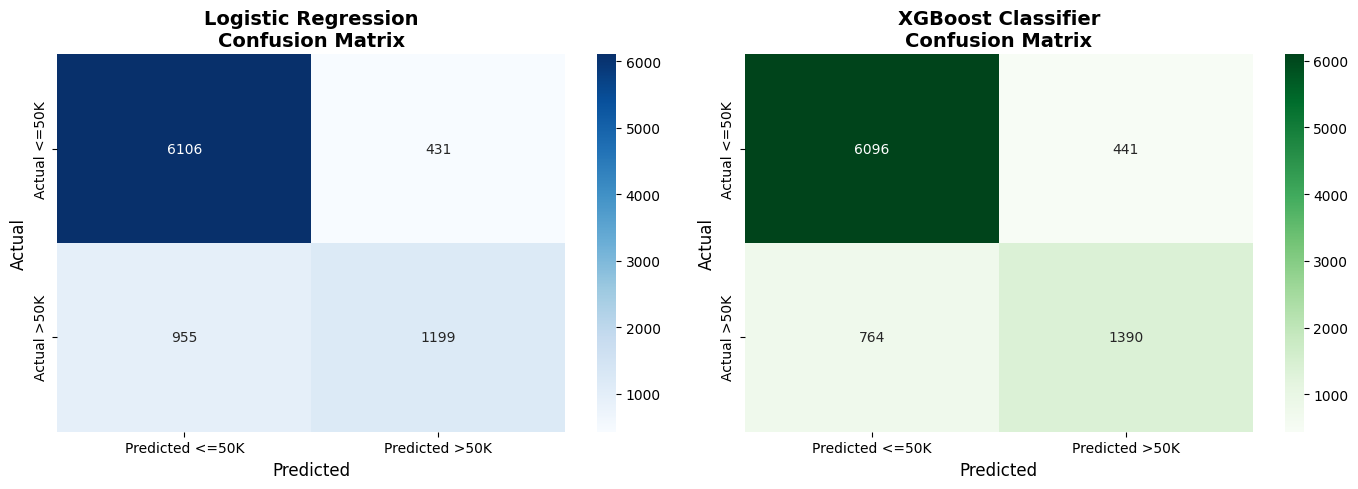

✓ Confusion matrices plotted


In [15]:
print("\n=== VISUALIZATIONS ===")

# Create side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression heatmap
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted <=50K', 'Predicted >50K'],
            yticklabels=['Actual <=50K', 'Actual >50K'])
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# XGBoost heatmap
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Predicted <=50K', 'Predicted >50K'],
            yticklabels=['Actual <=50K', 'Actual >50K'])
axes[1].set_title('XGBoost Classifier\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.show()

print("✓ Confusion matrices plotted")

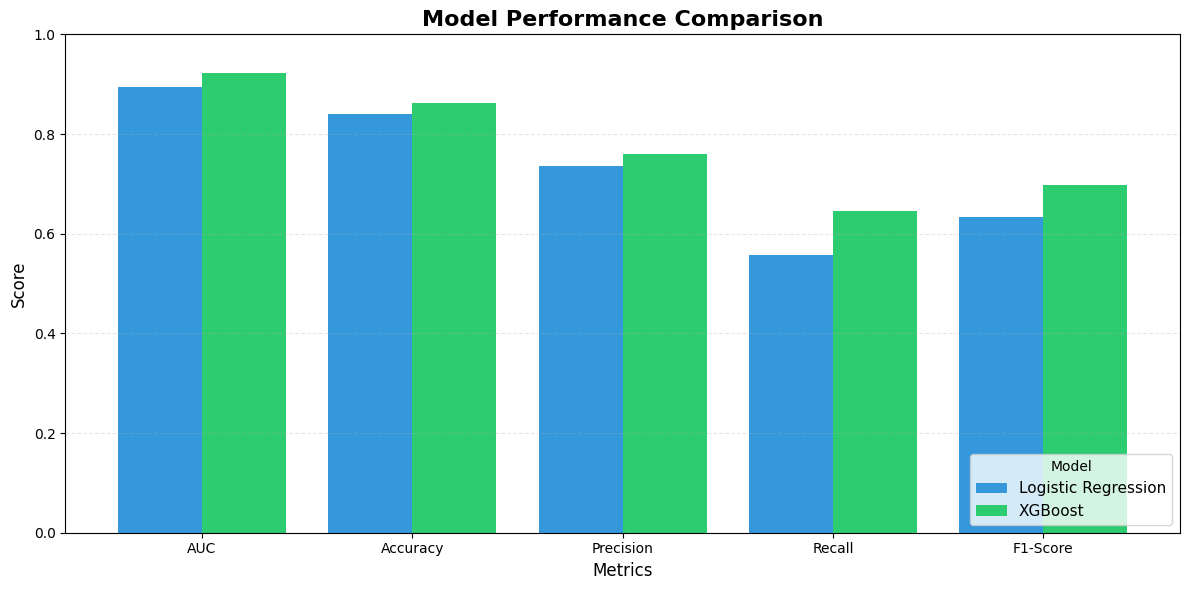

✓ Comparison chart plotted


In [16]:
# Bar chart comparing all metrics
fig, ax = plt.subplots(figsize=(12, 6))

results_df.T.plot(kind='bar', ax=ax, rot=0, width=0.8, color=['#3498db', '#2ecc71'])
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1)
ax.legend(title='Model', fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("✓ Comparison chart plotted")


=== FEATURE IMPORTANCE (XGBOOST) ===

Top 15 Most Important Features:
                              Feature  Importance
15  marital_status_married-civ-spouse    0.481564
4                        capital_gain    0.113020
22             relationship_own-child    0.068868
1                           education    0.049527
5                        capital_loss    0.037034
11         workclass_self-emp-not-inc    0.016384
24                  relationship_wife    0.016031
2                       education_num    0.014730
3                                 sex    0.014542
0                                 age    0.014419
28                         race_white    0.014194
6                      hours_per_week    0.014108
14   marital_status_married-af-spouse    0.013882
10             workclass_self-emp-inc    0.013518
21        relationship_other-relative    0.013436


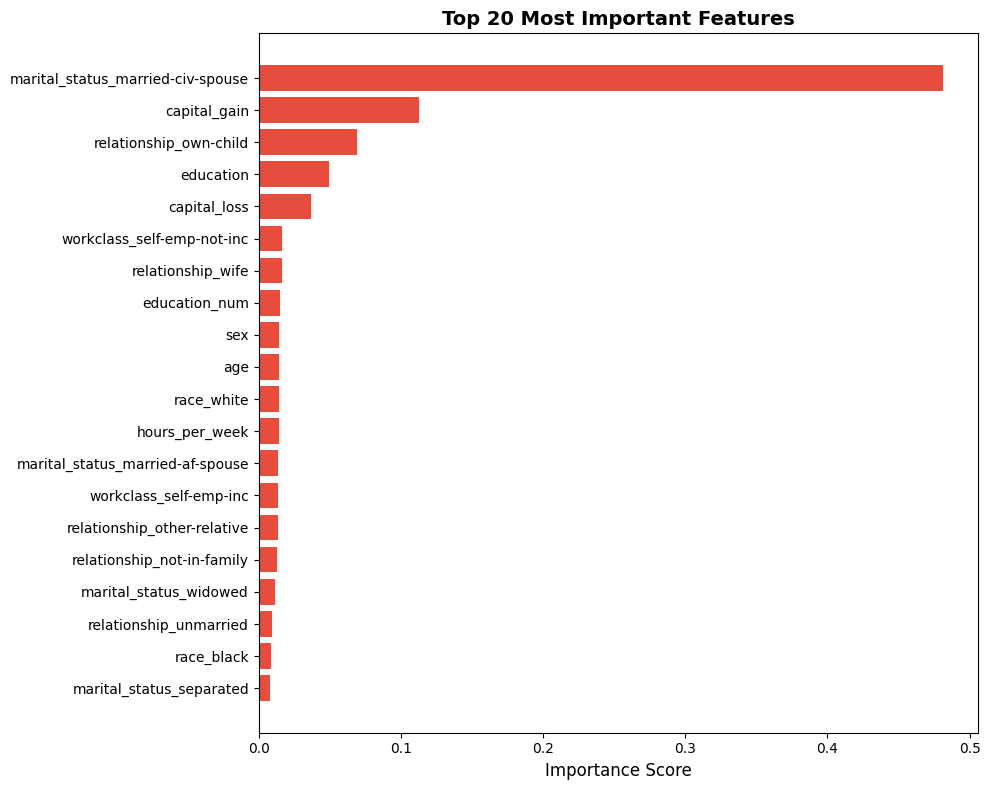

✓ Feature importance plotted


In [17]:
print("\n=== FEATURE IMPORTANCE (XGBOOST) ===")

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15))

# Plot top 20 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['Importance'], color='#e74c3c')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 20 Most Important Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("✓ Feature importance plotted")

In [19]:
# Assuming 'xgb_metrics' and 'lr_metrics' dictionaries are already defined from previous cells

print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

print(f"""
Key Findings:
-------------
1. Overall Predictive Power (AUC):
    - XGBoost: {xgb_metrics['AUC']:.4f} {'✓ SUPERIOR' if xgb_metrics['AUC'] > lr_metrics['AUC'] else ''}
    - Logistic Regression: {lr_metrics['AUC']:.4f}
    
2. Precision (Quality of positive predictions):
    - Logistic Regression: {lr_metrics['Precision']:.4f} {'✓ SUPERIOR' if lr_metrics['Precision'] > xgb_metrics['Precision'] else ''}
    - XGBoost: {xgb_metrics['Precision']:.4f}
    
3. Recall (Coverage of actual positives):
    - XGBoost: {xgb_metrics['Recall']:.4f} {'✓ SUPERIOR' if xgb_metrics['Recall'] > lr_metrics['Recall'] else ''}
    - Logistic Regression: {lr_metrics['Recall']:.4f}

Recommendations:
----------------
✓ For MAXIMUM PREDICTIVE POWER (AUC & Recall) → Use **XGBoost**
  (Best for: Maximizing correct identifications of positives, e.g., fraud detection or disease screening.)
  
✓ For HIGHEST POSITIVE PREDICTION QUALITY (Precision) → Use **Logistic Regression**
  (Best for: Scenarios where false positives are very costly, e.g., confirming a high-cost intervention.)
  
✓ For INTERPRETABILITY → Use **Logistic Regression**
  (Best for: Regulatory compliance, explainable decisions, and understanding feature relationships.)
""")

print("="*70)
print("Analysis Complete!")
print("="*70)


MODEL COMPARISON SUMMARY

Key Findings:
-------------
1. Overall Predictive Power (AUC):
    - XGBoost: 0.9226 ✓ SUPERIOR
    - Logistic Regression: 0.8948
    
2. Precision (Quality of positive predictions):
    - Logistic Regression: 0.7356 
    - XGBoost: 0.7591
    
3. Recall (Coverage of actual positives):
    - XGBoost: 0.6453 ✓ SUPERIOR
    - Logistic Regression: 0.5566

Recommendations:
----------------
✓ For MAXIMUM PREDICTIVE POWER (AUC & Recall) → Use **XGBoost**
  (Best for: Maximizing correct identifications of positives, e.g., fraud detection or disease screening.)
  
✓ For HIGHEST POSITIVE PREDICTION QUALITY (Precision) → Use **Logistic Regression**
  (Best for: Scenarios where false positives are very costly, e.g., confirming a high-cost intervention.)
  
✓ For INTERPRETABILITY → Use **Logistic Regression**
  (Best for: Regulatory compliance, explainable decisions, and understanding feature relationships.)

Analysis Complete!
